<a href="https://colab.research.google.com/github/ReproAnalytics/nmr-ovarian-follicle-ml/blob/main/PS_ROC_and_ML_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Set up Environment ##

# To ensure fastai install without error, use the following commands to force installation without any requirements to get the core library
%pip install --no-deps fastai fastcore

# Install the missing 'distutils' support
%pip install "setuptools<65"

# Manually install critical dependencies that are compatible
%pip install matplotlib pandas requests pyyaml packaging fastprogress

# Attempt to install a specific version of spacy that avoids the build
%pip install spacy --only-binary=:all:

# Install openslide for downstream implemetation of WSI
%pip install openslide-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.6 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [ ]:
# Install the system-level OpenSlide library
!sudo apt-get update
!sudo apt-get install openslide-tools
!pip install openslide-python

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,309 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,803 kB]
Get:12 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,842 kB]
Get:14 h

In [ ]:
# Import all necessary packages
import fastai
print(fastai.__version__)

from fastai.vision.all import *
import json
import os
from pathlib import Path
from PIL import Image, ImageDraw
import pandas as pd
import numpy as np
import openslide
import torch

2.8.7


In [ ]:
# Force CPU if GPU causes crashes to back up pipeline, suggested by multiple resources
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#print("Using device:", device)

#PS NOTE: since trying in google colab, trying without this section first

In [ ]:
!git clone https://github.com/ReproAnalytics/nmr-ovarian-follicle-ml.git

Cloning into 'nmr-ovarian-follicle-ml'...
remote: Enumerating objects: 1560, done.
remote: Counting objects: 100% (520/520), done.
remote: Compressing objects: 100% (492/492), done.
remote: Total 1560 (delta 123), reused 36 (delta 28), pack-reused 1040 (from 1)
Receiving objects: 100% (1560/1560), 33.07 MiB | 38.31 MiB/s, done.
Resolving deltas: 100% (423/423), done.


In [ ]:
import os
# Change 'YourRepoName' to the actual folder name that appeared in your sidebar
repo_path = "/content/nmr-ovarian-follicle-ml"
print(os.listdir(repo_path))

['.git', 'LICENSE', 'tests', 'torch', 'environment', 'images', 'manuscript', 'README.md', 'annotations', 'scripts', 'CNN', '.github', 'EDA', 'src', 'run', '.gitattributes', 'CONTRIBUTING.md', 'metadata_cellcountdata.py', 'configs', 'outputs', 'git_setup.sh', 'scaffold_project.sh', '.gitignore', 'QuPath']


Classes: ['astral', 'atretic antral', 'germ', 'multilayer', 'primary', 'primordial', 'stroma', 'transitional primordial']


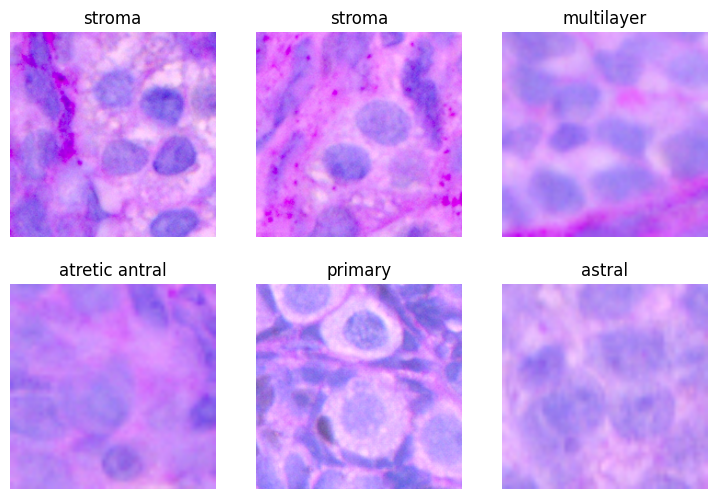

In [ ]:
# Load the QuPath tiles and build the fastai dataset loader with the pathway

path = Path('/content/nmr-ovarian-follicle-ml/CNN') # made changes because I cloned from git

dls = ImageDataLoaders.from_folder(
    path,
    train = 'train',
    valid = 'valid',
    item_tfms = Resize(224),
    batch_tfms = Normalize.from_stats(*imagenet_stats),
    bs = 16)

# Display the Qupath classification groups
print("Classes:", dls.vocab)
dls.show_batch(max_n = 6)

In [ ]:
# Initialize the model and identifying the best resnet34 model
# Confirm that these metircs are of interest with pretrained weights from imagenet (normalized above)

learn = cnn_learner(
    dls,
    resnet34,
    metrics = error_rate)

learn.model.to(device)

/usr/local/lib/python3.12/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 108MB/s]


NameError: name 'device' is not defined

In [ ]:
# Initiate callbacks

from fastai.callback.tracker import EarlyStoppingCallback, SaveModelCallback

early_stop = EarlyStoppingCallback(monitor='valid_loss', patience = 20)
save_best = SaveModelCallback(monitor='valid_loss', fname='best_resnet34')

## freeze and train the head of the resnet34

learn.fine_tune(
    5,
    base_lr=1e-3,
    cbs=[
        EarlyStoppingCallback(monitor='valid_loss', patience=3),
        SaveModelCallback(monitor='valid_loss', fname='best_resnet34')
    ]
)

# unfreeze the CNN and open back up to run though all the layers with a set number of epochs

learn.unfreeze()

learn.fit_one_cycle(
    10,
    lr_max=slice(1e-5, 1e-3),
    cbs=[
        EarlyStoppingCallback(monitor='valid_loss', patience=3),
        SaveModelCallback(monitor='valid_loss', fname='best_resnet34')
    ]
)

epoch,train_loss,valid_loss,error_rate,time
0,2.689905,1.431696,0.464286,02:20


Better model found at epoch 0 with valid_loss value: 1.4316962957382202.


epoch,train_loss,valid_loss,error_rate,time
0,1.573509,0.974007,0.369048,03:18
1,1.211043,0.916476,0.345238,03:21
2,0.927822,0.853306,0.333333,03:18
3,0.733885,0.784905,0.261905,03:15
4,0.579777,0.803684,0.297619,03:16


Better model found at epoch 0 with valid_loss value: 0.9740073084831238.
Better model found at epoch 1 with valid_loss value: 0.9164758324623108.
Better model found at epoch 2 with valid_loss value: 0.8533061742782593.
Better model found at epoch 3 with valid_loss value: 0.784904956817627.


epoch,train_loss,valid_loss,error_rate,time
0,0.421417,0.783126,0.297619,03:20
1,0.439110,1.121641,0.321429,03:16
2,0.406873,1.124970,0.345238,03:17
3,0.437497,1.174675,0.321429,03:18


Better model found at epoch 0 with valid_loss value: 0.783126175403595.
No improvement since epoch 0: early stopping


In [ ]:
# load the best resnet34 model model

learn.load('best_resnet34')
learn.model.eval()

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:67: UserWarning: Saved file doesn't contain an optimizer state.
  elif with_opt: warn("Saved file doesn't contain an optimizer state.")


Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

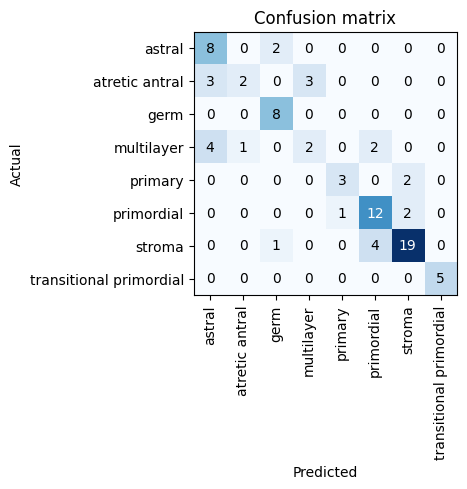

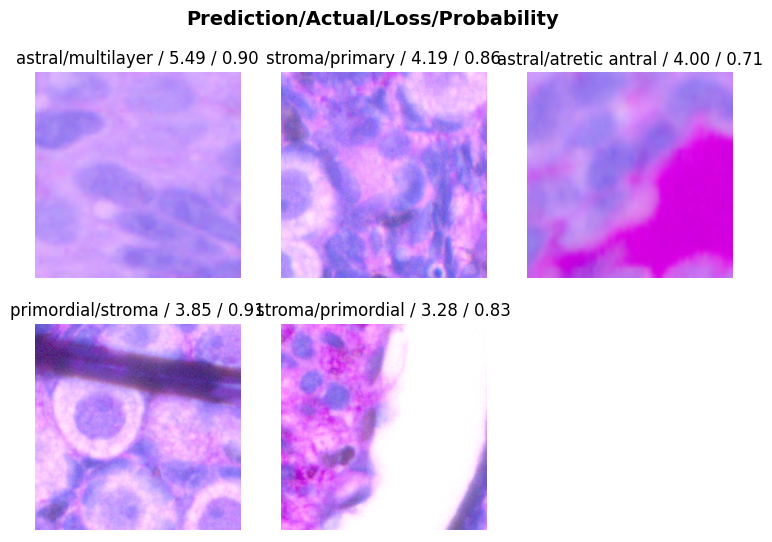

In [ ]:
# evaluate the model with a confusion matrix

interp = ClassificationInterpretation.from_learner(learn)

interp.plot_confusion_matrix()
interp.plot_top_losses(5)

In [ ]:
#################### place holder to find where I am working easier
### note because of pip install / pytorch issues I am having trouble testing this

Prediction Classes are ['astral', 'atretic antral', 'germ', 'multilayer', 'primary', 'primordial', 'stroma', 'transitional primordial']


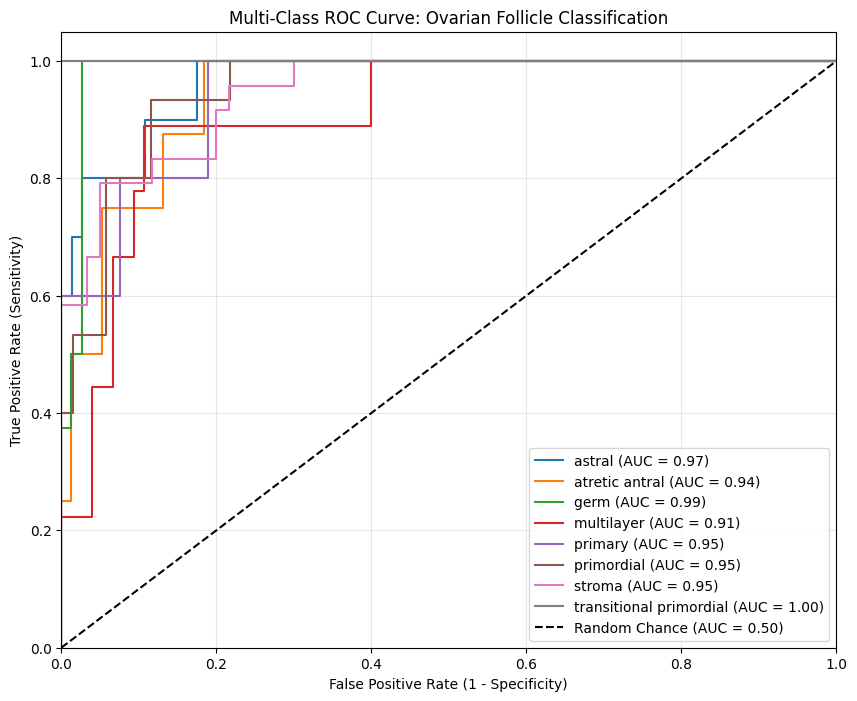

In [ ]:
################ adding ROC curve right after confusion matrix ##################
# based on version 5 of script from 03.27.2026

preds, targs = learn.get_preds()
print(f"Prediction Classes are {dls.vocab}")

# ROC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Create a plot
plt.figure(figsize=(10, 8))

# Loop through each of your 8 classes
for i, class_name in enumerate(dls.vocab):
    # Convert targets to binary (1 if it's this class, 0 if not)
    fpr, tpr, _ = roc_curve((targs == i).numpy(), preds[:, i].numpy())
    roc_auc = auc(fpr, tpr)

    # Plot the line for this specific follicle type
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')

# Plot the 'Random Chance' diagonal line (the Data Professor's dashed line)
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Multi-Class ROC Curve: Ovarian Follicle Classification')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [2]:
##################################
# Run a subset of tiles for tile-level testing

tile_dir = Path('/content/nmr-ovarian-follicle-ml/CNN') # change path to local or git clone depending on usage

counts = {cls: 0 for cls in dls.vocab}
results = []

for img_path in tile_dir.glob("*.png"):
    pred, pred_idx, probs = learn.predict(img_path)

    counts[str(pred)] += 1

    results.append({
        "tile": str(img_path),
        "prediction": str(pred),
        "confidence": float(probs[pred_idx])
    })

pd.DataFrame(results).to_csv("tile_predictions.csv", index=False)
pd.DataFrame([counts]).to_csv("tile_counts_summary.csv", index=False)

print("Tile Counts:", counts)

NameError: name 'Path' is not defined

In [ ]:
###### Test on Whole Slide Images of the H. glaber dataset (MAY WANT TO DIVIDE THESE SCRIPTS) #######

In [ ]:
# To input the larger TIFF files, install and import a WSI reader

%pip install openslide-python

In [ ]:
# Tile the whole slide image before execting the CNN (remove background first)

# Remove background on an elementary level
def is_tissue(tile, threshold = 220):
    """Simple background filter"""
    arr = np.array(tile)
    return np.mean(arr) < threshold

def tile_wsi(slide, level = 0, tile_size = 224, stride = 224):
    width, height = slide.level_dimensions[level]

    tiles = []
    coords = []

    for y in range(0, height - tile_size, stride):
        for x in range(0, width - tile_size, stride):
            tile = slide.read_region((x, y), level, (tile_size, tile_size)).convert("RGB")
        if is_tissue(tile):
            tiles.append(tile)
            coords.append((x, y))

    return tiles, coords

In [ ]:
# Actively run the trained CNN on the WSI tiles for fast WSI inference

def analyze_wsi(slide_path, learn, level = 1):
    print(f"\nProcessing: {slide_path}")

    slide = openslide.OpenSlide(slide_path)

    tiles, coords = tile_wsi(slide, level=level)

    if len(tiles) == 0:
        print("No tissue detected.")
        return None

    # Iniatiate rapid inference predictions in batch (make sure to set a counter)

    dl = learn.dls.test_dl(tiles)
    preds, _ = learn.get_preds(dl=dl)

    pred_classes = preds.argmax(dim=1)

    counts = {cls: 0 for cls in learn.dls.vocab}
    spatial_results = []

    for i, cls_idx in enumerate(pred_classes):
        label = learn.dls.vocab[cls_idx]
        counts[label] += 1

        x, y = coords[i]
        spatial_results.append({
            "x": x,
            "y": y,
            "prediction": label
        })

    return counts, spatial_results


In [ ]:
# Access the .tif files from the MOTHER database using the scripts/download_mother_nmr.sh

import subprocess
from pathlib import Path

# Directory where WSI files should be stored
download_dir = Path('/content/nmr-ovarian-follicle-ml/CNN') # path updated to use git clone
download_dir.mkdir(parents=True, exist_ok=True)

# Path to your .sh script (adjust if needed)
download_script = "scripts/download_mother_nmr.sh"

# Check if any .tif files already exist
tif_files = list(download_dir.rglob("*.tif"))

if len(tif_files) == 0:
    print("No WSI .tif files found. Running download script...")

    try:
        subprocess.run(["bash", download_script], check=True)
    except subprocess.CalledProcessError:
        raise RuntimeError("Download script failed. Check your .sh file.")

    # Re-scan after download
    tif_files = list(download_dir.rglob("*.tif"))

    if len(tif_files) == 0:
        raise RuntimeError("Download completed but no .tif files were found.")

else:
    print(f"Found {len(tif_files)} existing .tif files. Skipping download.")

# Final list of slide paths
slide_paths = tif_files

In [ ]:
# Run through all WSI files for H. glaber pulled from the MOTHER database

all_results = []

for slide_path in slide_paths:
    output = analyze_wsi(slide_path, learn)

    if output is None:
        continue

    counts, spatial = output

    print(f"\nResults for {Path(slide_path).name}:")
    print("Counts:", counts)

    # Save per-slide results
    slide_name = Path(slide_path).stem

    pd.DataFrame([counts]).to_csv(f"{slide_name}_counts.csv", index=False)
    pd.DataFrame(spatial).to_csv(f"{slide_name}_spatial.csv", index=False)

    all_results.append({
        "slide": slide_name,
        **counts
    })

In [ ]:
# Save a summary of the overall pipeline

pd.DataFrame(all_results).to_csv("all_slides_summary.csv", index=False)

print("\nPipeline complete.")